# GVH_Duffing_Pipeline_0.1

Pipeline GVH appliqué à l’oscillateur de Duffing.

Version : 0.1  
Statut : descriptif, reproductible, sans interprétation Volume Partagé.

## 1. Objectif

Ce notebook applique le pipeline GVH à l’oscillateur de Duffing, un système dynamique non linéaire forcé.

L’objectif est de construire une trajectoire dynamique reproductible, puis de calculer les observables GVH suivantes :

- \(D_T\)
- \(S_T\)
- \(S_T^{\rm norm}\)
- \(D_c\)
- \(R_{\rm super}\)
- \(A_H\)
- \(B_H\)
- \(\theta_{\rm mean}\)
- \(\theta_{\max}\)
- \(R_{180}\)

Cette version 0.1 est strictement descriptive. Elle ne propose aucune interprétation Volume Partagé.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit

import sys
import scipy

## 2. Définition du système de Duffing

On considère l’oscillateur de Duffing forcé :

\[
\ddot{x} + \delta \dot{x} + \alpha x + \beta x^3 = \gamma \cos(\omega t)
\]

En posant \(v = \dot{x}\), le système devient :

\[
\dot{x} = v
\]

\[
\dot{v} = -\delta v - \alpha x - \beta x^3 + \gamma \cos(\omega t)
\]

Les paramètres utilisés ici correspondent à un régime non linéaire forcé permettant de produire une dynamique riche.

In [3]:
# Paramètres du système de Duffing
delta = 0.2
alpha = -1.0
beta = 1.0
gamma = 0.3
omega = 1.2

# Conditions initiales
x0 = 0.1
v0 = 0.0
y0 = [x0, v0]

# Domaine temporel
t_min = 0.0
t_max = 500.0
n_time = 20000

t_eval = np.linspace(t_min, t_max, n_time)

print("Paramètres Duffing :")
print(f"delta = {delta}")
print(f"alpha = {alpha}")
print(f"beta  = {beta}")
print(f"gamma = {gamma}")
print(f"omega = {omega}")
print(f"conditions initiales : x0={x0}, v0={v0}")
print(f"t ∈ [{t_min}, {t_max}], N={n_time}")

Paramètres Duffing :
delta = 0.2
alpha = -1.0
beta  = 1.0
gamma = 0.3
omega = 1.2
conditions initiales : x0=0.1, v0=0.0
t ∈ [0.0, 500.0], N=20000


In [4]:
def duffing_system(t, y, delta, alpha, beta, gamma, omega):
    x, v = y

    dxdt = v
    dvdt = -delta * v - alpha * x - beta * x**3 + gamma * np.cos(omega * t)

    return [dxdt, dvdt]

3 — Génération de la trajectoire

In [5]:
solution = solve_ivp(
    fun=lambda t, y: duffing_system(
        t, y,
        delta,
        alpha,
        beta,
        gamma,
        omega
    ),
    t_span=(t_min, t_max),
    y0=y0,
    t_eval=t_eval,
    method="RK45",
    rtol=1e-9,
    atol=1e-12
)

# Extraction de la trajectoire
t = solution.t
x = solution.y[0]
v = solution.y[1]

print("Intégration terminée.")
print(f"Succès : {solution.success}")
print(f"Message : {solution.message}")
print(f"Nombre de points : {len(t)}")
print(f"x min / max : {x.min():.6f} / {x.max():.6f}")
print(f"v min / max : {v.min():.6f} / {v.max():.6f}")

Intégration terminée.
Succès : True
Message : The solver successfully reached the end of the integration interval.
Nombre de points : 20000
x min / max : -1.482806 / 1.435088
v min / max : -0.837045 / 0.877027


série temporelle x(t)

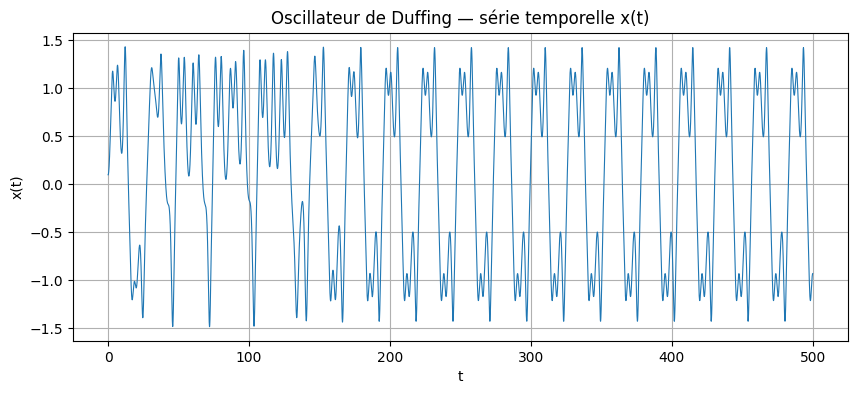

In [6]:
plt.figure(figsize=(10, 4))
plt.plot(t, x, linewidth=0.8)
plt.xlabel("t")
plt.ylabel("x(t)")
plt.title("Oscillateur de Duffing — série temporelle x(t)")
plt.grid(True)
plt.show()

série temporelle v(t)

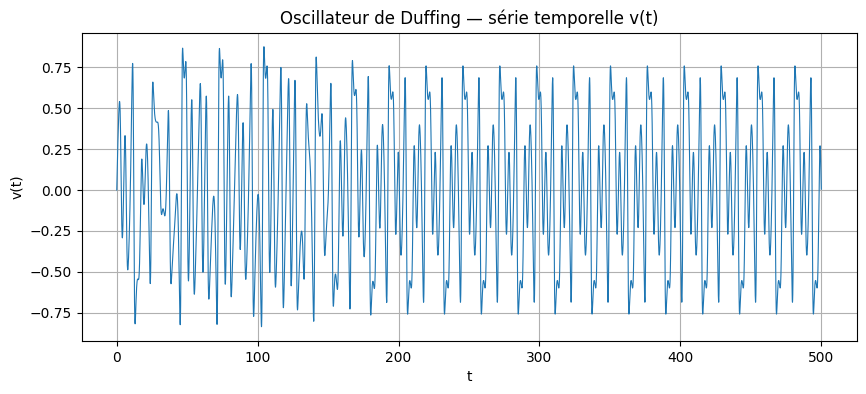

In [7]:
plt.figure(figsize=(10, 4))
plt.plot(t, v, linewidth=0.8)
plt.xlabel("t")
plt.ylabel("v(t)")
plt.title("Oscillateur de Duffing — série temporelle v(t)")
plt.grid(True)
plt.show()

portrait de phase

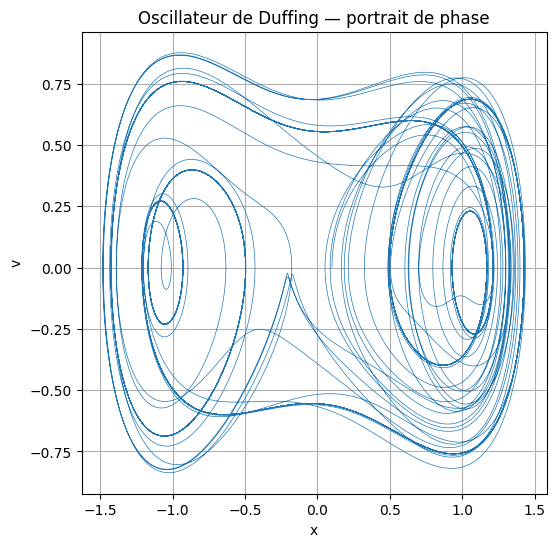

In [9]:
plt.figure(figsize=(6, 6))
plt.plot(x, v, linewidth=0.5)
plt.xlabel("x")
plt.ylabel("v")
plt.title("Oscillateur de Duffing — portrait de phase")
plt.grid(True)
plt.show()

Construction GVH

## 4. Construction GVH

À partir de la trajectoire de Duffing \((x(t), v(t))\), on construit une représentation géométrique dynamique.

On définit le champ scalaire :

\[
T(t) = \sqrt{x(t)^2 + v(t)^2}
\]

Puis on calcule une variation locale :

\[
D_T(t) = \left|\frac{dT}{dt}\right|
\]

Cette construction permet d’appliquer les observables GVH à la trajectoire dynamique sans introduire d’interprétation physique supplémentaire.


In [10]:
# Construction du signal GVH à partir de la trajectoire Duffing
T = np.sqrt(x**2 + v**2)

# Variation locale
D_T = np.abs(np.gradient(T, t))

print("Construction GVH terminée.")
print(f"T min / max : {T.min():.6f} / {T.max():.6f}")
print(f"D_T min / max : {D_T.min():.6f} / {D_T.max():.6f}")
print(f"D_T moyen   : {D_T.mean():.6f}")

Construction GVH terminée.
T min / max : 0.052153 / 1.489274
D_T min / max : 0.000000 / 0.859211
D_T moyen   : 0.293183


signal T(t)

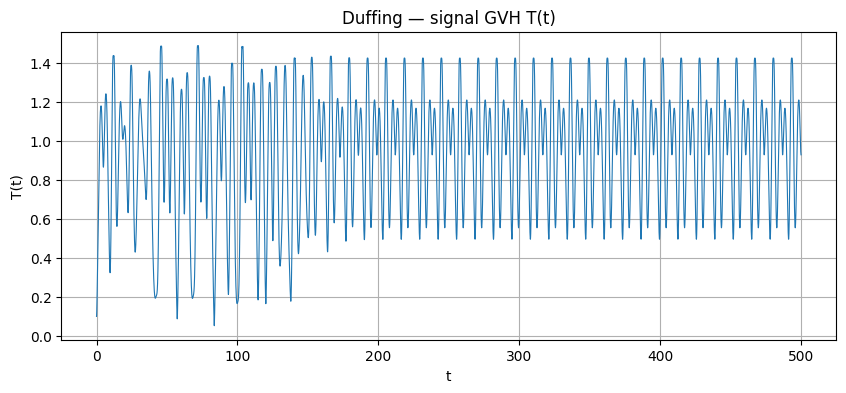

In [11]:
plt.figure(figsize=(10, 4))
plt.plot(t, T, linewidth=0.8)
plt.xlabel("t")
plt.ylabel("T(t)")
plt.title("Duffing — signal GVH T(t)")
plt.grid(True)
plt.show()

observable locale D_T(t)

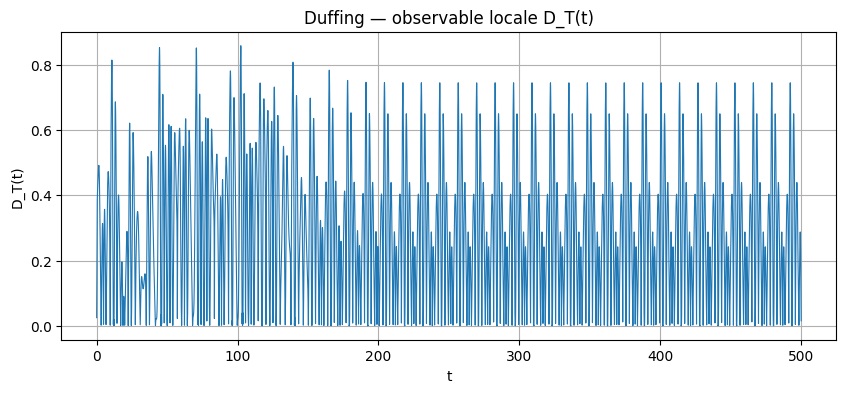

In [12]:
plt.figure(figsize=(10, 4))
plt.plot(t, D_T, linewidth=0.8)
plt.xlabel("t")
plt.ylabel("D_T(t)")
plt.title("Duffing — observable locale D_T(t)")
plt.grid(True)
plt.show()

distribution de D_T

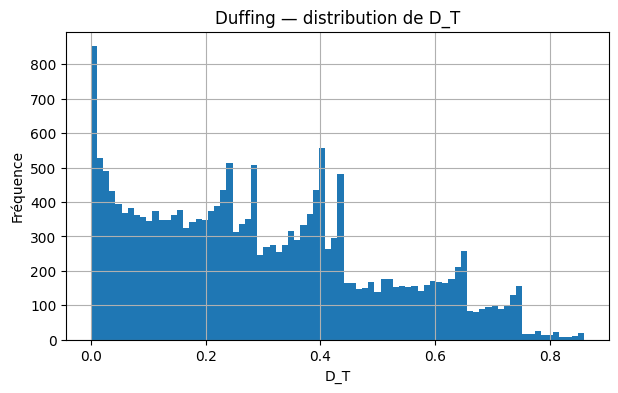

In [13]:
plt.figure(figsize=(7, 4))
plt.hist(D_T, bins=80)
plt.xlabel("D_T")
plt.ylabel("Fréquence")
plt.title("Duffing — distribution de D_T")
plt.grid(True)
plt.show()

calcul des observables GVH complètes.

## 5. Calcul des observables GVH

Les observables GVH sont calculées à partir de la distribution de \(D_T\).

On utilise :

- \(D_T^{\rm mean}\) : moyenne de \(D_T\)
- \(S_T\) : écart-type de \(D_T\)
- \(S_T^{\rm norm} = S_T / D_T^{\rm mean}\)
- \(D_c\) : seuil critique défini par le 95e percentile de \(D_T\)
- \(R_{\rm super}\) : fraction des points tels que \(D_T > D_c\)

Les observables \(A_H\) et \(B_H\) sont ensuite obtenues par ajustement exponentiel de la fonction de survie de \(D_T\).

Les observables angulaires sont calculées séparément à partir de la géométrie locale de la trajectoire.

In [14]:
# Observables GVH de base
D_T_mean = np.mean(D_T)
S_T = np.std(D_T)
S_T_norm = S_T / D_T_mean

# Seuil critique
D_c = np.percentile(D_T, 95)

# Fraction supercritique
R_super = np.mean(D_T > D_c)

print("Observables GVH de base :")
print(f"D_T_mean  = {D_T_mean:.6f}")
print(f"S_T       = {S_T:.6f}")
print(f"S_T_norm  = {S_T_norm:.6f}")
print(f"D_c       = {D_c:.6f}")
print(f"R_super   = {R_super:.6f}")

Observables GVH de base :
D_T_mean  = 0.293183
S_T       = 0.203821
S_T_norm  = 0.695200
D_c       = 0.665159
R_super   = 0.050000


ajustement A_H, B_H

In [15]:
# Fonction de survie empirique de D_T
D_sorted = np.sort(D_T)
survival = 1.0 - np.arange(1, len(D_sorted) + 1) / len(D_sorted)

# On évite les valeurs nulles pour le log
mask = survival > 0
D_fit = D_sorted[mask]
S_fit = survival[mask]

# Zone d'ajustement : queue supérieure
q_min = np.percentile(D_T, 50)
fit_mask = D_fit >= q_min

D_fit_tail = D_fit[fit_mask]
S_fit_tail = S_fit[fit_mask]

def exponential_model(D, A, B):
    return A * np.exp(-B * D)

popt, pcov = curve_fit(
    exponential_model,
    D_fit_tail,
    S_fit_tail,
    p0=(1.0, 1.0),
    maxfev=10000
)

A_H, B_H = popt

print("Ajustement exponentiel GVH :")
print(f"A_H = {A_H:.6f}")
print(f"B_H = {B_H:.6f}")

Ajustement exponentiel GVH :
A_H = 1.909376
B_H = 4.784771


### Observables angulaires

La géométrie locale de la trajectoire est étudiée à partir des vecteurs tangents successifs dans l’espace de phase \((x,v)\).

Pour chaque point intérieur de la trajectoire, on construit deux déplacements successifs :

\[
\mathbf{u}_i = \mathbf{r}_i - \mathbf{r}_{i-1}
\]

\[
\mathbf{w}_i = \mathbf{r}_{i+1} - \mathbf{r}_i
\]

L’angle local est défini par :

\[
\theta_i =
\arccos
\left(
\frac{
\mathbf{u}_i \cdot \mathbf{w}_i
}{
\|\mathbf{u}_i\|\,\|\mathbf{w}_i\|
}
\right)
\]

On calcule ensuite :

- \(\theta_{\rm mean}\)
- \(\theta_{\max}\)
- \(R_{180}\), fraction des angles proches de \(180^\circ\)

In [16]:
# Trajectoire dans l'espace de phase
trajectory = np.column_stack((x, v))

# Déplacements successifs
u = trajectory[1:-1] - trajectory[:-2]
w = trajectory[2:] - trajectory[1:-1]

# Normes
norm_u = np.linalg.norm(u, axis=1)
norm_w = np.linalg.norm(w, axis=1)

# Éviter les divisions par zéro
valid = (norm_u > 0) & (norm_w > 0)

u_valid = u[valid]
w_valid = w[valid]
norm_u_valid = norm_u[valid]
norm_w_valid = norm_w[valid]

# Cosinus des angles
cos_theta = np.sum(u_valid * w_valid, axis=1) / (
    norm_u_valid * norm_w_valid
)

# Sécurité numérique
cos_theta = np.clip(cos_theta, -1.0, 1.0)

# Angles en degrés
theta = np.degrees(np.arccos(cos_theta))

# Observables angulaires
theta_mean = np.mean(theta)
theta_max = np.max(theta)

# Opposition proche de 180°
R_180 = np.mean(theta >= 170.0)

print("Observables angulaires GVH :")
print(f"theta_mean = {theta_mean:.6f} deg")
print(f"theta_max  = {theta_max:.6f} deg")
print(f"R_180      = {R_180:.6f}")

Observables angulaires GVH :
theta_mean = 1.746517 deg
theta_max  = 17.910256 deg
R_180      = 0.000000


tableau récapitulatif

In [17]:
observables = pd.DataFrame({
    "Observable": [
        "D_T_mean",
        "S_T",
        "S_T_norm",
        "D_c",
        "R_super",
        "A_H",
        "B_H",
        "theta_mean",
        "theta_max",
        "R_180"
    ],
    "Valeur": [
        D_T_mean,
        S_T,
        S_T_norm,
        D_c,
        R_super,
        A_H,
        B_H,
        theta_mean,
        theta_max,
        R_180
    ]
})

observables

,Observable,Valeur
0,D_T_mean,0.293183
1,S_T,0.203821
2,S_T_norm,0.695200
3,D_c,0.665159
4,R_super,0.050000
5,A_H,1.909376
6,B_H,4.784771
7,theta_mean,1.746517
8,theta_max,17.910256
9,R_180,0.000000


In [18]:
observables = pd.DataFrame({
    "Observable": [
        "D_T_mean",
        "S_T",
        "S_T_norm",
        "D_c",
        "R_super",
        "A_H",
        "B_H",
        "theta_mean",
        "theta_max",
        "R_180"
    ],
    "Valeur": [
        D_T_mean,
        S_T,
        S_T_norm,
        D_c,
        R_super,
        A_H,
        B_H,
        theta_mean,
        theta_max,
        R_180
    ]
})

observables

,Observable,Valeur
0,D_T_mean,0.293183
1,S_T,0.203821
2,S_T_norm,0.695200
3,D_c,0.665159
4,R_super,0.050000
5,A_H,1.909376
6,B_H,4.784771
7,theta_mean,1.746517
8,theta_max,17.910256
9,R_180,0.000000


Courbe de survie et ajustement exponentiel

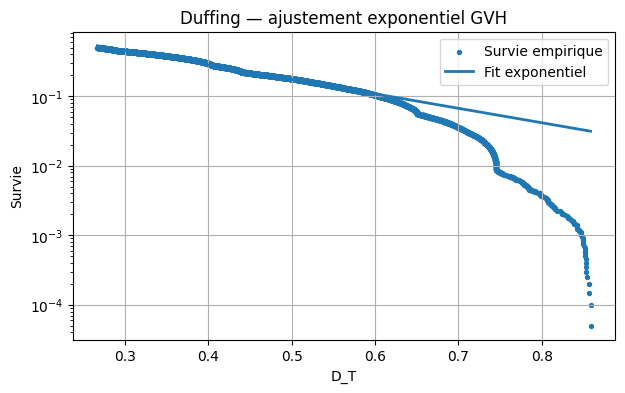

In [19]:
plt.figure(figsize=(7, 4))
plt.scatter(D_fit_tail, S_fit_tail, s=8, label="Survie empirique")
plt.plot(D_fit_tail, exponential_model(D_fit_tail, A_H, B_H), linewidth=2, label="Fit exponentiel")
plt.xlabel("D_T")
plt.ylabel("Survie")
plt.title("Duffing — ajustement exponentiel GVH")
plt.yscale("log")
plt.grid(True)
plt.legend()
plt.show()

Distribution des angles

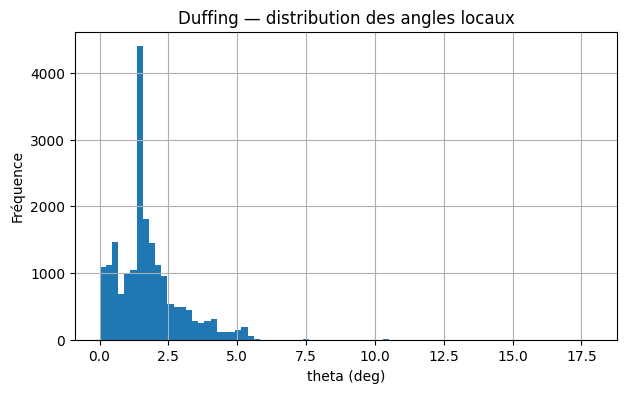

In [20]:
plt.figure(figsize=(7, 4))
plt.hist(theta, bins=80)
plt.xlabel("theta (deg)")
plt.ylabel("Fréquence")
plt.title("Duffing — distribution des angles locaux")
plt.grid(True)
plt.show()

qualité de l’ajustement exponentiel

In [21]:
# Prédiction du modèle exponentiel
S_pred = exponential_model(D_fit_tail, A_H, B_H)

# Coefficient de détermination R²
ss_res = np.sum((S_fit_tail - S_pred)**2)
ss_tot = np.sum((S_fit_tail - np.mean(S_fit_tail))**2)

R2_H = 1.0 - ss_res / ss_tot

# RMSE
RMSE_H = np.sqrt(np.mean((S_fit_tail - S_pred)**2))

print("Diagnostic du fit exponentiel GVH :")
print(f"R2_H   = {R2_H:.6f}")
print(f"RMSE_H = {RMSE_H:.6f}")

Diagnostic du fit exponentiel GVH :
R2_H   = 0.983905
RMSE_H = 0.018309


robustesse aux fenêtres

In [22]:
# Test de robustesse du fit exponentiel
quantiles = [40, 50, 60, 70]

robustness_results = []

for q in quantiles:

    q_min_test = np.percentile(D_T, q)
    mask_test = D_fit >= q_min_test

    D_test = D_fit[mask_test]
    S_test = S_fit[mask_test]

    try:
        popt_test, _ = curve_fit(
            exponential_model,
            D_test,
            S_test,
            p0=(1.0, 1.0),
            maxfev=10000
        )

        A_test, B_test = popt_test

        S_pred_test = exponential_model(
            D_test,
            A_test,
            B_test
        )

        ss_res_test = np.sum(
            (S_test - S_pred_test)**2
        )

        ss_tot_test = np.sum(
            (S_test - np.mean(S_test))**2
        )

        R2_test = 1.0 - ss_res_test / ss_tot_test

        robustness_results.append({
            "Quantile_min": q,
            "A_H": A_test,
            "B_H": B_test,
            "R2_H": R2_test
        })

    except RuntimeError:
        robustness_results.append({
            "Quantile_min": q,
            "A_H": np.nan,
            "B_H": np.nan,
            "R2_H": np.nan
        })

robustness_df = pd.DataFrame(robustness_results)

robustness_df

,Quantile_min,A_H,B_H,R2_H
0,40,1.603409,4.360753,0.984612
1,50,1.909376,4.784771,0.983905
2,60,2.710078,5.569574,0.989613
3,70,2.836401,5.672418,0.978890


### Commentaire sur la robustesse

Le test de robustesse montre que l’ajustement exponentiel reste de bonne qualité pour plusieurs fenêtres de départ.

Les valeurs de \(R_H^2\) restent élevées, entre environ 0.979 et 0.990.

Cependant, \(B_H\) varie de manière non négligeable selon la fenêtre d’ajustement. Dans cette version 0.1, \(B_H\) doit donc être interprété comme un paramètre descriptif dépendant de la convention de fit, et non comme une constante universelle du système.

Export CSV

## 9. Export des résultats

Les résultats du pipeline sont exportés sous forme de fichiers CSV afin de permettre leur réutilisation, leur comparaison avec d’autres systèmes dynamiques et leur archivage reproductible.

Trois fichiers sont produits :

- observables GVH finales ;
- trajectoire dynamique et variables GVH locales ;
- résultats du test de robustesse aux fenêtres d’ajustement.

In [23]:
trajectory_df = pd.DataFrame({
    "t": t,
    "x": x,
    "v": v,
    "T": T,
    "D_T": D_T
})

trajectory_df.head()

,t,x,v,T,D_T
0,0.000000,0.100000,0.000000,0.100000,0.024708
1,0.025001,0.100124,0.009950,0.100618,0.048775
2,0.050003,0.100497,0.019851,0.102439,0.095404
3,0.075004,0.101117,0.029700,0.105388,0.138485
4,0.100005,0.101982,0.039498,0.109363,0.177202


In [24]:
# Noms des fichiers
observables_file = "GVH_Duffing_Observables_0.1.csv"
trajectory_file = "GVH_Duffing_Trajectory_0.1.csv"
robustness_file = "GVH_Duffing_Robustness_0.1.csv"

# Exports
observables.to_csv(
    observables_file,
    index=False
)

trajectory_df.to_csv(
    trajectory_file,
    index=False
)

robustness_df.to_csv(
    robustness_file,
    index=False
)

print("Exports terminés :")
print(f"- {observables_file}")
print(f"- {trajectory_file}")
print(f"- {robustness_file}")

Exports terminés :
- GVH_Duffing_Observables_0.1.csv
- GVH_Duffing_Trajectory_0.1.csv
- GVH_Duffing_Robustness_0.1.csv


Reproductibilité

## 10. Reproductibilité

Cette section documente l’environnement numérique, les paramètres du système de Duffing et les paramètres d’intégration utilisés dans cette version 0.1.

Le système étudié est déterministe et aucune composante aléatoire n’est utilisée dans le pipeline principal. Aucun seed n’est donc requis pour cette exécution de référence.

De faibles différences numériques peuvent néanmoins apparaître entre versions de Python, NumPy ou SciPy, notamment en raison de l’intégration adaptative et des routines d’optimisation.

Les observables GVH doivent donc être comparées à tolérance numérique près plutôt que par identité bit à bit.

In [25]:
print("Environnement numérique :")
print(f"Python : {sys.version}")
print(f"NumPy  : {np.__version__}")
print(f"SciPy  : {scipy.__version__}")
print(f"pandas : {pd.__version__}")

Environnement numérique :
Python : 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
NumPy  : 2.0.2
SciPy  : 1.16.3
pandas : 2.2.2


In [26]:
reference_parameters = pd.DataFrame({
    "Parametre": [
        "delta",
        "alpha",
        "beta",
        "gamma",
        "omega",
        "x0",
        "v0",
        "t_min",
        "t_max",
        "n_time",
        "methode_integration",
        "rtol",
        "atol",
        "quantile_D_c",
        "quantile_fit_principal",
        "seuil_R_180_deg"
    ],
    "Valeur": [
        delta,
        alpha,
        beta,
        gamma,
        omega,
        x0,
        v0,
        t_min,
        t_max,
        n_time,
        "RK45",
        1e-9,
        1e-12,
        95,
        50,
        170
    ]
})

reference_parameters

,Parametre,Valeur
0,delta,0.2
1,alpha,-1.0
2,beta,1.0
3,gamma,0.3
4,omega,1.2
5,x0,0.1
6,v0,0.0
7,t_min,0.0
8,t_max,500.0
9,n_time,20000


In [27]:
pd.set_option("display.float_format", "{:.12g}".format)
reference_parameters

,Parametre,Valeur
0,delta,0.2
1,alpha,-1
2,beta,1
3,gamma,0.3
4,omega,1.2
5,x0,0.1
6,v0,0
7,t_min,0
8,t_max,500
9,n_time,20000


## 11. Conclusion descriptive

Le notebook `GVH_Duffing_Pipeline_0.1` applique le pipeline GVH à l’oscillateur de Duffing forcé.

L’intégration numérique du système a été réalisée avec succès sur \(N=20000\) points temporels, pour \(t \in [0,500]\). La trajectoire obtenue reste bornée, avec une dynamique non linéaire visible dans les séries temporelles et le portrait de phase.

La construction GVH repose sur le signal :

\[
T(t)=\sqrt{x(t)^2+v(t)^2}
\]

et sur l’observable locale :

\[
D_T(t)=\left|\frac{dT}{dt}\right|.
\]

Les observables principales obtenues sont :

- \(D_T^{\rm mean}=0.293183\)
- \(S_T=0.203821\)
- \(S_T^{\rm norm}=0.695200\)
- \(D_c=0.665159\)
- \(R_{\rm super}=0.050000\)
- \(A_H=1.909376\)
- \(B_H=4.784771\)
- \(\theta_{\rm mean}=1.746517^\circ\)
- \(\theta_{\max}=17.910256^\circ\)
- \(R_{180}=0.000000\)

L’ajustement exponentiel associé à \(A_H\) et \(B_H\) présente une bonne qualité globale sur la fenêtre choisie, avec :

\[
R_H^2=0.983905,
\qquad
\mathrm{RMSE}_H=0.018309.
\]

Le test de robustesse montre que la qualité du fit reste élevée pour plusieurs fenêtres d’ajustement, mais que \(B_H\) varie de manière non négligeable selon la fenêtre. Dans cette version 0.1, \(B_H\) doit donc être interprété comme un paramètre descriptif dépendant de la convention de fit.

Les observables angulaires montrent une trajectoire localement lisse dans l’espace de phase \((x,v)\), avec une absence d’opposition angulaire proche de \(180^\circ\), confirmée par \(R_{180}=0\).

Cette version constitue un pipeline descriptif et reproductible pour Duffing, sans interprétation Volume Partagé.